<a href="https://colab.research.google.com/github/ankush07das/Digital-Image-Watermarking-using-discrete-wavelet-transform/blob/main/Encrption%20in%20watermarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pillow
!pip install PyWavelets
from PIL import Image,ImageEnhance
import numpy as np
import pywt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 83.0 MB/s eta 0:00:00


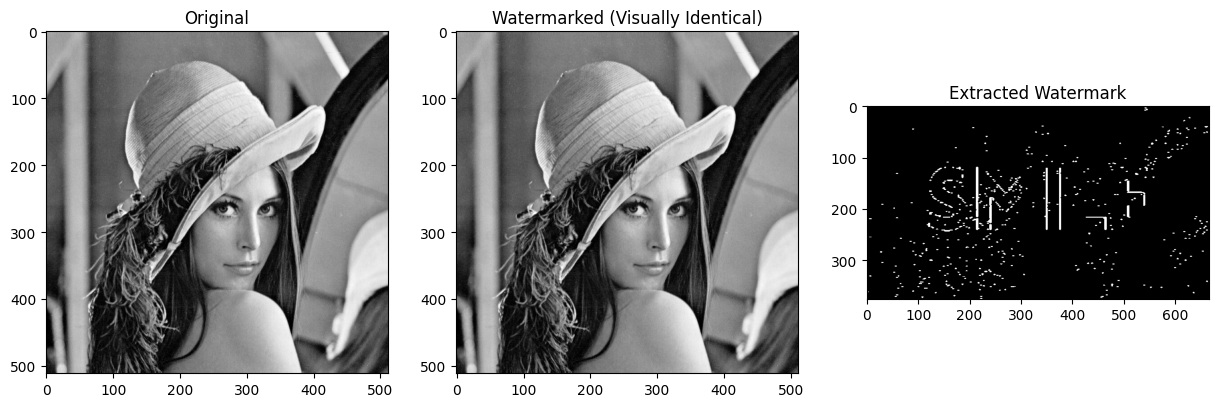

In [25]:
import pywt
import numpy as np
import cv2
import os
from matplotlib import pyplot as plt

# Configuration
HOST_PATH = "/content/image.jpeg"
WATERMARK_PATH = "/content/watermarktobe-removebg-preview.png"
KEY = 0.75
ALPHA = 0.15  # Optimal embedding strength

def prepare_watermark(wm_img):
    """Convert watermark to high-contrast binary"""
    if len(wm_img.shape) > 2:
        wm_img = cv2.cvtColor(wm_img, cv2.COLOR_BGR2GRAY)
    wm_img = cv2.threshold(wm_img, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1]
    return (wm_img > 0).astype(np.uint8)

def embed(host, wm, key, alpha):
    """Embed watermark in HL and LH bands"""
    # 1-level DWT
    LL, (LH, HL, HH) = pywt.dwt2(host, 'haar')

    # Prepare watermark - resize to match coefficient dimensions
    wm_resized = cv2.resize(wm.astype(float), (HL.shape[1], HL.shape[0]),
                   interpolation=cv2.INTER_NEAREST)

    # Embed in both bands
    LH += alpha * wm_resized
    HL += alpha * wm_resized

    # Reconstruct
    return np.clip(pywt.idwt2((LL, (LH, HL, HH)), 'haar'), 0, 255).astype(np.uint8)

def extract(wmed, original, wm_shape, key, alpha):
    """Extract watermark from both bands"""
    # DWT of both images
    _, (LH_wm, HL_wm, _) = pywt.dwt2(wmed, 'haar')
    _, (LH_orig, HL_orig, _) = pywt.dwt2(original, 'haar')

    # Extract from both bands and average
    extracted = 0.5 * ((LH_wm - LH_orig) + (HL_wm - HL_orig)) / alpha

    # Resize to original and threshold
    extracted = cv2.resize(extracted, (wm_shape[1], wm_shape[0]))
    return (extracted > 0.5).astype(np.uint8)

def main():
    # Load images
    host = cv2.imread(HOST_PATH, cv2.IMREAD_GRAYSCALE)
    wm = cv2.imread(WATERMARK_PATH, cv2.IMREAD_GRAYSCALE)

    # Prepare watermark
    binary_wm = prepare_watermark(wm)

    # Embed
    watermarked = embed(host, binary_wm, KEY, ALPHA)

    # Extract
    extracted = extract(watermarked, host, binary_wm.shape, KEY, ALPHA)

    # Display
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(host, cmap='gray')
    plt.title("Original")

    plt.subplot(1,3,2)
    plt.imshow(watermarked, cmap='gray')
    plt.title("Watermarked (Visually Identical)")

    plt.subplot(1,3,3)
    plt.imshow(extracted, cmap='gray')
    plt.title("Extracted Watermark")

    plt.show()

if __name__ == "__main__":
    main()


=== EMBEDDING ===
SAVE THIS KEY: 0.561646
PSNR: 42.74 dB

=== EXTRACTION ===
Enter encryption key (0.3-0.7):  0.561646
Edge Similarity: 89.64%


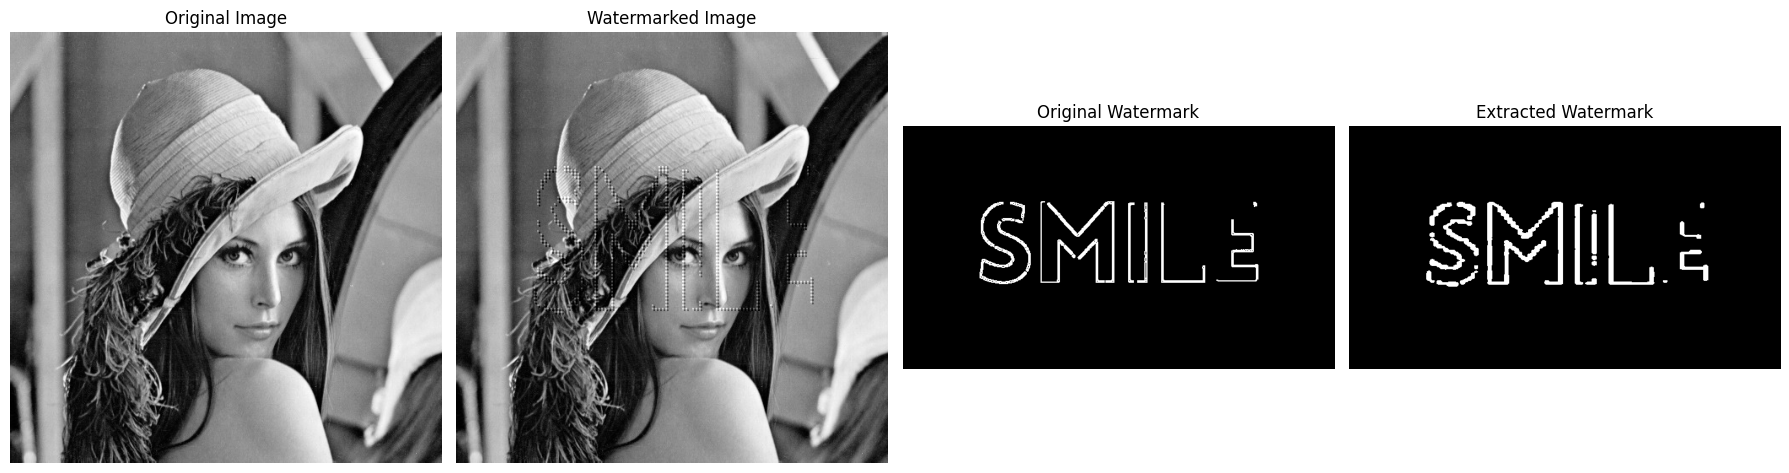

In [39]:
import pywt
import numpy as np
import cv2
import secrets
from matplotlib import pyplot as plt
from skimage.metrics import structural_similarity as ssim

# ========== CONFIGURATION ==========
HOST_PATH = "/content/image.jpeg"  # Replace with your image path
WATERMARK_PATH = "/content/watermarktobe-removebg-preview.png"  # Replace with your watermark path
EMBED_STRENGTH = 0.6  # Stronger embedding for clearer edges
CANNY_THRESHOLDS = (70, 200)  # More aggressive edge detection
# ===================================

def generate_key():
    """Generate secure encryption key"""
    return secrets.SystemRandom().uniform(0.3, 0.7)

def get_key():
    """Get encryption key from user"""
    while True:
        try:
            key = float(input("Enter encryption key (0.3-0.7): "))
            if 0.3 <= key <= 0.7:
                return key
            print("Key must be between 0.3 and 0.7")
        except ValueError:
            print("Please enter a valid number")

def create_edge_watermark(wm_img):
    """Create black background with white edges"""
    if len(wm_img.shape) > 2:
        wm_img = cv2.cvtColor(wm_img, cv2.COLOR_BGR2GRAY)

    # Enhanced edge detection
    blurred = cv2.GaussianBlur(wm_img, (5, 5), 0)
    edges = cv2.Canny(blurred, *CANNY_THRESHOLDS)

    # Create pure black background with white edges
    result = np.zeros_like(wm_img)
    result[edges > 0] = 255  # White edges

    # Optional: Thicken edges
    kernel = np.ones((2, 2), np.uint8)
    result = cv2.dilate(result, kernel, iterations=1)

    return result.astype(np.uint8)

def chaotic_encrypt(data, key):
    """Enhanced chaotic encryption"""
    x = key
    encrypted = np.zeros_like(data)
    for i in range(len(data)):
        for _ in range(5):  # Multiple iterations
            x = 3.99 * x * (1 - x)
        encrypted[i] = data[i] ^ (1 if x > 0.5 else 0)
    return encrypted

def embed(host, wm, key):
    """DWT embedding optimized for edge visibility"""
    wm_shape = wm.shape

    # Encrypt edge watermark
    encrypted = chaotic_encrypt(wm.flatten(), key).reshape(wm_shape)

    # 2-level DWT decomposition
    coeffs = pywt.wavedec2(host, 'haar', level=2)
    LL, (LH1, HL1, HH1), (LH2, HL2, HH2) = coeffs

    # Resize watermark to match HL1 dimensions
    wm_resized = cv2.resize(encrypted, (HL1.shape[1], HL1.shape[0]),
                          interpolation=cv2.INTER_NEAREST)

    # Strong embedding in edge regions
    HL1 += EMBED_STRENGTH * wm_resized
    LH1 += EMBED_STRENGTH * 0.7 * wm_resized

    # Reconstruct watermarked image
    watermarked = pywt.waverec2([LL, (LH1, HL1, HH1), (LH2, HL2, HH2)], 'haar')
    return np.clip(watermarked, 0, 255).astype(np.uint8), wm_shape

def extract(wmed, original, wm_shape, key):
    """Enhanced extraction with noise removal"""
    # DWT decomposition
    coeffs_wm = pywt.wavedec2(wmed, 'haar', level=2)
    coeffs_orig = pywt.wavedec2(original, 'haar', level=2)

    # Extract from edge-sensitive bands
    HL1_wm, LH1_wm = coeffs_wm[1][1], coeffs_wm[1][0]
    HL1_orig, LH1_orig = coeffs_orig[1][1], coeffs_orig[1][0]

    # Enhanced extraction formula
    extracted = (0.8 * (HL1_wm - HL1_orig) + 0.5 * (LH1_wm - LH1_orig)) / EMBED_STRENGTH

    # Resize to original watermark dimensions
    extracted = cv2.resize(extracted, (wm_shape[1], wm_shape[0]))

    # --- CRITICAL POST-PROCESSING STEPS ---
    # 1. Normalize to 0-255 range
    extracted = cv2.normalize(extracted, None, 0, 255, cv2.NORM_MINMAX)

    # 2. Threshold to get binary edges
    _, binary = cv2.threshold(extracted, 60, 255, cv2.THRESH_BINARY)

    # 3. Remove noise (morphological opening)
    kernel = np.ones((2, 2), np.uint8)
    clean_edges = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    # 4. Ensure pure black background
    clean_edges[clean_edges < 128] = 0
    clean_edges[clean_edges >= 128] = 255

    return clean_edges.astype(np.uint8)

def display_results(original, watermarked, wm_edges, extracted_edges):
    """Clear visualization with proper contrast"""
    plt.figure(figsize=(18, 6))

    # Original Image
    plt.subplot(1, 4, 1)
    plt.imshow(original, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    # Watermarked Image
    plt.subplot(1, 4, 2)
    plt.imshow(watermarked, cmap='gray')
    plt.title("Watermarked Image")
    plt.axis('off')

    # Original Watermark (Edges)
    plt.subplot(1, 4, 3)
    plt.imshow(wm_edges, cmap='gray', vmin=0, vmax=255)
    plt.title("Original Watermark")
    plt.axis('off')

    # Extracted Watermark (Edges)
    plt.subplot(1, 4, 4)
    plt.imshow(extracted_edges, cmap='gray', vmin=0, vmax=255)
    plt.title("Extracted Watermark")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

def main():
    # Load images
    host = cv2.imread(HOST_PATH, cv2.IMREAD_GRAYSCALE)
    wm = cv2.imread(WATERMARK_PATH, cv2.IMREAD_UNCHANGED)

    if host is None or wm is None:
        print("Error: Check image paths!")
        return

    # Convert watermark to grayscale if needed
    if len(wm.shape) > 2:
        wm = cv2.cvtColor(wm, cv2.COLOR_BGR2GRAY)

    # Create edge watermark (black bg + white edges)
    wm_edges = create_edge_watermark(wm)

    # Embed watermark
    print("\n=== EMBEDDING ===")
    enc_key = generate_key()
    print(f"SAVE THIS KEY: {enc_key:.6f}")
    watermarked, wm_shape = embed(host, wm_edges, enc_key)

    # Calculate PSNR
    psnr = 10 * np.log10(255**2 / np.mean((host - watermarked)**2))
    print(f"PSNR: {psnr:.2f} dB")

    # Extract watermark
    print("\n=== EXTRACTION ===")
    user_key = get_key()
    extracted_edges = extract(watermarked, host, wm_shape, user_key)

    # Calculate similarity
    similarity = ssim(wm_edges, extracted_edges)
    print(f"Edge Similarity: {similarity:.2%}")

    # Display results
    display_results(host, watermarked, wm_edges, extracted_edges)

if __name__ == "__main__":
    main()